# Lead Scoring — Exploratory Data Analysis (EDA)

BizPilot AI · Week 3 lead-scoring dataset exploration.

This notebook explores the Kaggle **Lead Scoring** dataset used to train the
lead-qualification model. It reuses the same cleaning logic as
`src/lead_scoring_baseline.py` so the EDA matches what the model sees.

**Note:** the raw CSV (`data/lead_scoring/raw/Lead Scoring.csv`) is gitignored.
Place it there before running this notebook.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.lead_scoring_baseline import TARGET_COLUMN, clean_dataset, load_dataset

pd.set_option("display.max_columns", 60)
print("Root:", ROOT)

Root: c:\Users\Semih\Desktop\BizPilot AI


## 1. Load raw and cleaned data

In [2]:
df_raw = load_dataset()
df_clean = clean_dataset(df_raw)
print(f"Raw shape:   {df_raw.shape}")
print(f"Clean shape: {df_clean.shape}")
df_raw.head()

Raw shape:   (9240, 37)
Clean shape: (7484, 28)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


## 2. Target balance (Converted)

How many leads actually converted? Class balance drives the choice of
`class_weight="balanced"` in the model.

Converted
0    4519
1    2965
Name: count, dtype: int64
Conversion rate: 39.6%


<Axes: title={'center': 'Converted (0 = no, 1 = yes)'}, xlabel='Converted'>

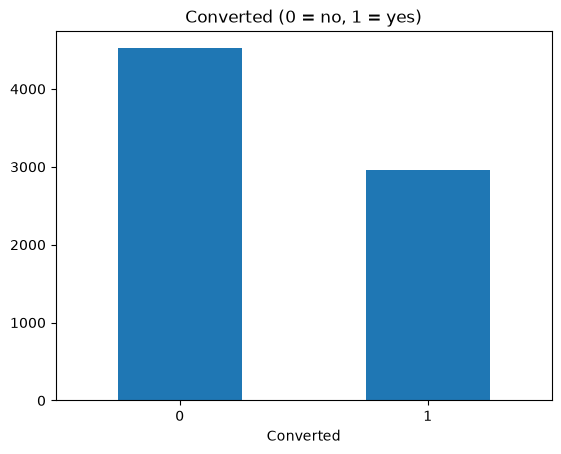

In [3]:
counts = df_clean[TARGET_COLUMN].value_counts()
rate = df_clean[TARGET_COLUMN].mean()
print(counts)
print(f"Conversion rate: {rate:.1%}")
counts.plot(kind="bar", title="Converted (0 = no, 1 = yes)", rot=0)

## 3. Missing values

Top columns by missing count after `Select` -> NA replacement.

In [4]:
missing = df_clean.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(15)

How did you hear about X Education               5494
City                                             1984
What matters most to you in choosing a course    1921
What is your current occupation                  1902
Specialization                                   1802
Country                                           711
Page Views Per Visit                              136
TotalVisits                                       136
Last Activity                                     102
Lead Source                                        23
dtype: int64

## 4. Numeric feature distributions

In [5]:
numeric_cols = df_clean.select_dtypes(include="number").drop(columns=[TARGET_COLUMN]).columns
df_clean[numeric_cols].describe()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,7348.000000,7484.000000,7348.000000
mean,4.266739,601.784874,2.925796
std,5.069104,549.536711,2.034827
min,0.000000,0.000000,0.000000
25%,2.000000,139.000000,2.000000
50%,3.000000,365.000000,2.500000
75%,5.000000,1080.000000,4.000000
max,251.000000,2272.000000,55.000000


array([[<Axes: title={'center': 'TotalVisits'}>,
        <Axes: title={'center': 'Total Time Spent on Website'}>],
       [<Axes: title={'center': 'Page Views Per Visit'}>, <Axes: >]],
      dtype=object)

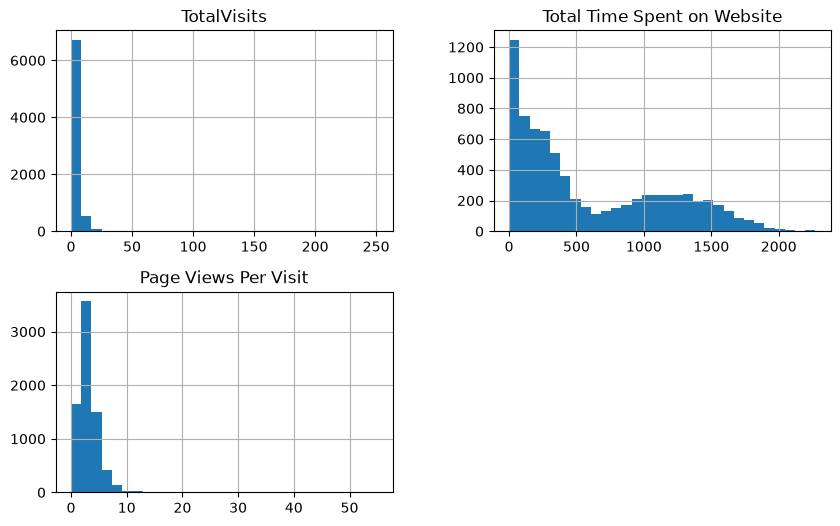

In [6]:
df_clean[numeric_cols].hist(figsize=(10, 6), bins=30)

## 5. Conversion rate by key categorical drivers

Which lead sources / origins convert best? These align with the rule-based
adjustments in `src/lead_scoring_predictor.py`.

In [7]:
for col in ["Lead Origin", "Lead Source", "What is your current occupation"]:
    if col in df_clean.columns:
        rates = df_clean.groupby(col)[TARGET_COLUMN].mean().sort_values(ascending=False)
        print(f"\n=== Conversion rate by {col} ===")
        print(rates.head(8).round(3))


=== Conversion rate by Lead Origin ===
Lead Origin
Quick Add Form             1.000
Lead Add Form              0.893
API                        0.388
Landing Page Submission    0.362
Lead Import                0.265
Name: Converted, dtype: float64

=== Conversion rate by Lead Source ===
Lead Source
Live Chat           1.000
WeLearn             1.000
NC_EDM              1.000
Welingak Website    0.961
Reference           0.898
Click2call          0.750
Olark Chat          0.504
Social Media        0.500
Name: Converted, dtype: float64

=== Conversion rate by What is your current occupation ===
What is your current occupation
Housewife               1.000
Working Professional    0.903
Businessman             0.625
Other                   0.625
Student                 0.428
Unemployed              0.420
Name: Converted, dtype: float64


## 6. Takeaways

- The dataset is moderately imbalanced, justifying `class_weight="balanced"`.
- Time-on-website and total visits correlate with conversion — these feed the
  rule adjustments in the scorer.
- Lead origin (e.g. *Lead Add Form*) and occupation (*Working Professional*)
  are strong categorical signals, matching the model's top coefficients in
  `reports/lead_scoring_baseline.md`.
- Model comparison (LogReg vs Random Forest vs XGBoost) is in
  `reports/lead_scoring_model_comparison.md`.